In [ ]:
import mediapipe as mp

from torch.utils.data import Dataset

import numpy as np

import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from tqdm import tqdm

import math

C:\Users\atom0\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [ ]:
import zipfile
import os

zip_path = "open_close_eye.zip"
extract_path = "dataset"
if os.path.exists(extract_path):
    print("Directory already exists:", extract_path)
    
else:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        
    print("Unzipped to:", extract_path)

Unzipped to: dataset


In [5]:
import random
class CustomDataset(Dataset):
    def __init__(self, path):
        self.path = path

        self.data = []
        self.labels = []

        categories = ['OpenFace', 'ClosedFace']
        for label, category in enumerate(categories):
            category_path = os.path.join(self.path, category)
            for img in os.listdir(category_path):
                self.data.append(os.path.join(category_path, img))
                self.labels.append(label)

        combined = list(zip(self.data, self.labels))
        random.shuffle(combined)
        self.data, self.labels = zip(*combined)
        self.data = list(self.data)
        self.labels = list(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]
        image = cv2.imread(img_path)
        return image, label


In [6]:
test_dataset = CustomDataset(os.path.join(extract_path,'dataset_B_FacialImages'))

In [7]:
def get_count(dataset):
  count = [0,0]
  for label in dataset.labels:
    count[label] += 1
  return count

test_count = get_count(test_dataset)

print(f'Test count: {test_count}')


Test count: [1232, 1193]


In [21]:
class EARClassifier:
    def __init__(self, threshold=0.2):
        self.threshold = threshold

        # Initialize MediaPipe Face Mesh for static images
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=True,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5
        )

        # Eye landmarks
        self.right_eye_idxs = [33, 160, 158, 133, 153, 144]
        self.left_eye_idxs = [362, 385, 387, 263, 373, 380]

    def normalized_to_pixel(self,normalized_x, normalized_y, image_width, image_height):
      x_px = min(int(normalized_x * image_width), image_width - 1)
      y_px = min(int(normalized_y * image_height), image_height - 1)
      return x_px, y_px

    def get_ear(self,landmarks, refer_idxs, frame_w, frame_h):
      try:
          coords_pts = []
          for i in refer_idxs:
              lm = landmarks[i]
              coord = self.normalized_to_pixel(lm.x,lm.y,frame_w,frame_h)

              coords_pts.append(coord)

          ear = self.eye_aspect_ratio(coords_pts)
      except:
          ear = 0.0
          coords_pts = None

      return ear, coords_pts

    def eye_aspect_ratio(self,eye):
      dist_p2_p6 = math.dist(eye[1],eye[5])
      dist_p3_p5 = math.dist(eye[2],eye[4])
      dist_p1_p4 = math.dist(eye[0],eye[3])

      if dist_p1_p4 == 0:
          return 0.0

      return (dist_p2_p6 + dist_p3_p5) / (2.0 * dist_p1_p4)

    def calculate_avg_ear(self,lms, left_eye_idxs, right_eye_idxs, image_w, image_h):
      left_ear, left_lm_coords = self.get_ear(lms,left_eye_idxs,image_w,image_h)
      right_ear, right_lm_coords = self.get_ear(lms,right_eye_idxs,image_w,image_h)

      avg_ear = (left_ear + right_ear) / 2.0

      return avg_ear, (left_lm_coords, right_lm_coords)

    def ear_detection(self,image: np.array):
      img = np.ascontiguousarray(image)
      img_h,img_w,_ = img.shape
      results = self.face_mesh.process(img)
      if results.multi_face_landmarks:
        landmarks = results.multi_face_landmarks[0].landmark
        ear, _ = self.calculate_avg_ear(
            landmarks,
            self.left_eye_idxs,
            self.right_eye_idxs,
            img_w,
            img_h
        )
        is_drowsy = ear < self.threshold
        return ear, is_drowsy
      return None, None

    def classify_image(self, img_bgr):
        """Classify a single image as drowsy or not."""
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return self.ear_detection(img_rgb)

In [ ]:
classifier = EARClassifier()

In [31]:
true_labels = []
predicted_labels = []
ears = []

for img, label in tqdm(test_dataset):
  if img is None:
        print("Warning: Image is corrupted, skipping...")
        continue
  ear, is_drowsy = classifier.classify_image(img)
  if is_drowsy is not None:
    ears.append(ear)
    predicted_labels.append(int(is_drowsy))
    true_labels.append(label)
  else:
    continue


 20%|██        | 491/2425 [00:10<00:42, 45.69it/s]

 79%|███████▉  | 1925/2425 [00:50<00:11, 43.27it/s]

100%|██████████| 2425/2425 [01:03<00:00, 38.25it/s]


In [ ]:
print(len(test_dataset))
print(len(true_labels))

2425
2397


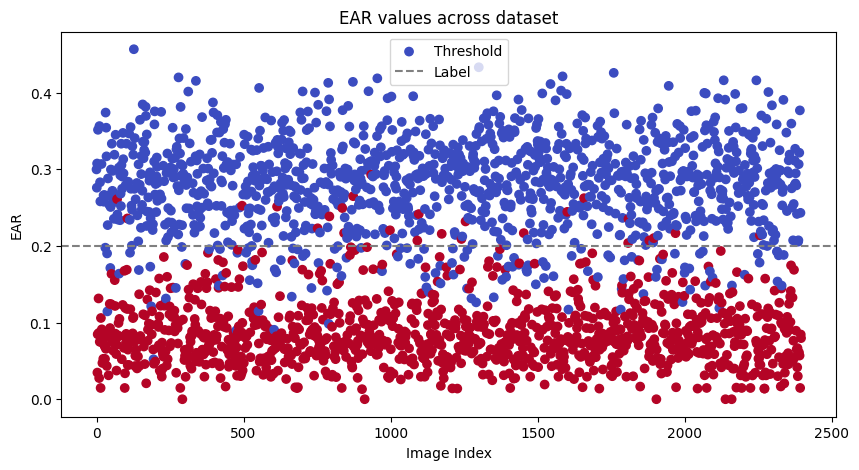

In [33]:
plt.figure(figsize=(10, 5))
plt.scatter(range(len(ears)), ears, c=true_labels, cmap='coolwarm', label=true_labels)
plt.axhline(classifier.threshold, color='gray', linestyle='--', label='Threshold')
plt.title('EAR values across dataset')
plt.ylabel('EAR')
plt.xlabel('Image Index')
plt.legend(['Threshold', 'Label'])
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

In [45]:
y_true = true_labels
y_pred = predicted_labels

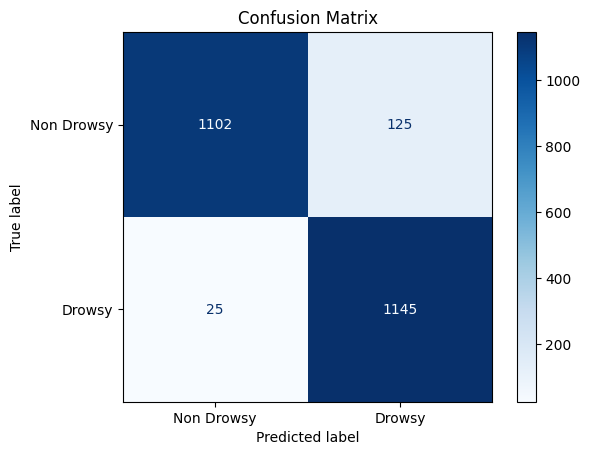

In [46]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non Drowsy', 'Drowsy'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [47]:
print(classification_report(y_true, y_pred, target_names=['Non Drowsy', 'Drowsy']))

              precision    recall  f1-score   support

  Non Drowsy       0.98      0.90      0.94      1227
      Drowsy       0.90      0.98      0.94      1170

    accuracy                           0.94      2397
   macro avg       0.94      0.94      0.94      2397
weighted avg       0.94      0.94      0.94      2397



Text(0, 0.5, 'Score')

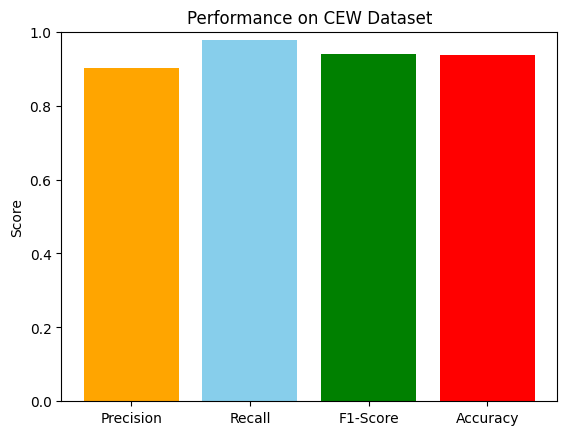

In [49]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

metrics = [precision, recall, f1, accuracy]
labels = ['Precision', 'Recall', 'F1-Score', 'Accuracy']

bars = plt.bar(labels, metrics, color=['orange', 'skyblue', 'green', 'red'])
plt.ylim(0, 1)
plt.title("Performance on CEW Dataset")
plt.ylabel("Score")